In [1]:
#Importovanje potrebnih biblioteka
from tensorflow import keras 
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from datetime import datetime

In [2]:
# Ucitavanje .csv fajla
df = pd.read_csv('beograd-air-quality.csv', delimiter=",")
Beograd = pd.DataFrame(df)
print(Beograd)
Beograd.dtypes

            date pm25 pm10   o3  no2 so2  co
0       2026/1/1   60              9   4   2
1       2026/1/2   38              7   3   2
2       2026/1/3   47              4   3   2
3       2026/1/4   56             10   4   3
4       2026/1/5   89              5   3   2
...          ...  ...  ...  ...  ...  ..  ..
3612   2017/3/28             17   23       5
3613   2017/3/29             22   11       4
3614  2025/12/31                  11   6   2
3615   2025/12/4                   4   4    
3616  2025/12/20                  10   5   4

[3617 rows x 7 columns]


date    object
pm25    object
pm10    object
o3      object
no2     object
so2     object
co      object
dtype: object

In [3]:
#Promena datatype u odgovarajuci format
Beograd[['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']] = Beograd[['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']].astype("string")
Beograd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3617 entries, 0 to 3616
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    3617 non-null   object
 1   pm25    3617 non-null   string
 2   pm10    3617 non-null   string
 3   o3      3617 non-null   string
 4   no2     3617 non-null   string
 5   so2     3617 non-null   string
 6   co      3617 non-null   string
dtypes: object(1), string(6)
memory usage: 197.9+ KB


In [4]:
#Promena datatype u odgovarajuci format
Beograd['pm25'] = pd.to_numeric(Beograd['pm25'], errors='coerce')
Beograd['pm10'] = pd.to_numeric(Beograd['pm10'], errors='coerce')
Beograd['o3'] = pd.to_numeric(Beograd['o3'], errors='coerce')
Beograd['no2'] = pd.to_numeric(Beograd['no2'], errors='coerce')
Beograd['so2'] = pd.to_numeric(Beograd['so2'], errors='coerce')
Beograd['co'] = pd.to_numeric(Beograd['co'], errors='coerce')
Beograd.info()
Beograd

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3617 entries, 0 to 3616
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    3617 non-null   object
 1   pm25    3430 non-null   Int64 
 2   pm10    3380 non-null   Int64 
 3   o3      3431 non-null   Int64 
 4   no2     3331 non-null   Int64 
 5   so2     1463 non-null   Int64 
 6   co      3455 non-null   Int64 
dtypes: Int64(6), object(1)
memory usage: 219.1+ KB


,date,pm25,pm10,o3,no2,so2,co
0,2026/1/1,60,<NA>,<NA>,9,4,2
1,2026/1/2,38,<NA>,<NA>,7,3,2
2,2026/1/3,47,<NA>,<NA>,4,3,2
3,2026/1/4,56,<NA>,<NA>,10,4,3
4,2026/1/5,89,<NA>,<NA>,5,3,2
...,...,...,...,...,...,...,...
3612,2017/3/28,<NA>,<NA>,17,23,<NA>,5
3613,2017/3/29,<NA>,<NA>,22,11,<NA>,4
3614,2025/12/31,<NA>,<NA>,<NA>,11,6,2
3615,2025/12/4,<NA>,<NA>,<NA>,4,4,<NA>


In [5]:
#Postavljanje date kolone na mesto index
Beograd.index = pd.to_datetime(Beograd["date"])
Beograd.sort_index(inplace=True)
Beograd.drop(columns=["date","so2"], inplace=True)
Beograd

,pm25,pm10,o3,no2,co
date,,,,,
2016-01-26,<NA>,71,<NA>,89,19
2016-01-27,171,79,<NA>,95,25
2016-01-28,175,54,<NA>,88,13
2016-01-29,142,51,<NA>,83,12
2016-01-30,136,12,<NA>,65,5
...,...,...,...,...,...
2026-01-16,130,<NA>,<NA>,5,2
2026-01-17,53,<NA>,<NA>,5,2
2026-01-18,74,<NA>,<NA>,6,2


In [6]:
#popunjavanje nedostajucih vrednosti
Beograd.ffill(inplace = True)
Beograd.bfill(inplace = True)
Beograd.head(20)

,pm25,pm10,o3,no2,co
date,,,,,
2016-01-26,171,71,5,89,19
2016-01-27,171,79,5,95,25
2016-01-28,175,54,5,88,13
2016-01-29,142,51,5,83,12
2016-01-30,136,12,5,65,5
2016-01-31,38,12,5,65,5
2016-02-03,38,23,5,36,6
2016-02-04,71,26,5,60,7
2016-02-05,81,26,5,64,8


In [7]:
# Kreiranje AQI kolone kao indeks zagadjenosti vazduha
Beograd['AQI'] = Beograd[['pm25','pm10','o3','no2','co']].max(axis=1)
Beograd


,pm25,pm10,o3,no2,co,AQI
date,,,,,,
2016-01-26,171,71,5,89,19,171
2016-01-27,171,79,5,95,25,171
2016-01-28,175,54,5,88,13,175
2016-01-29,142,51,5,83,12,142
2016-01-30,136,12,5,65,5,136
...,...,...,...,...,...,...
2026-01-16,130,16,10,5,2,130
2026-01-17,53,16,10,5,2,53
2026-01-18,74,16,10,6,2,74


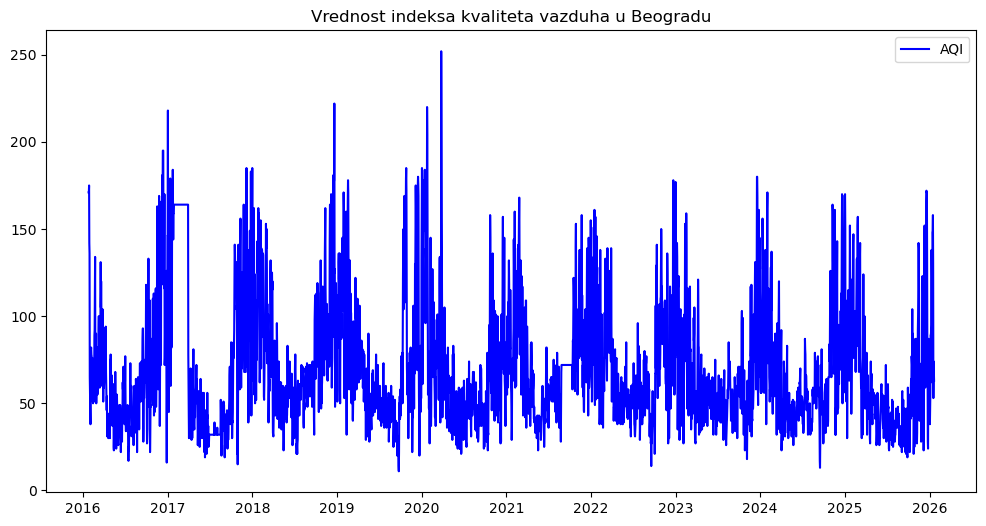

In [8]:
#Grafik za prikaz AQI
plt.figure(figsize=(12,6))
plt.plot(Beograd.index, Beograd['AQI'], label = "AQI", color = "blue")
plt.title("Vrednost indeksa kvaliteta vazduha u Beogradu")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Matrica korelacije')

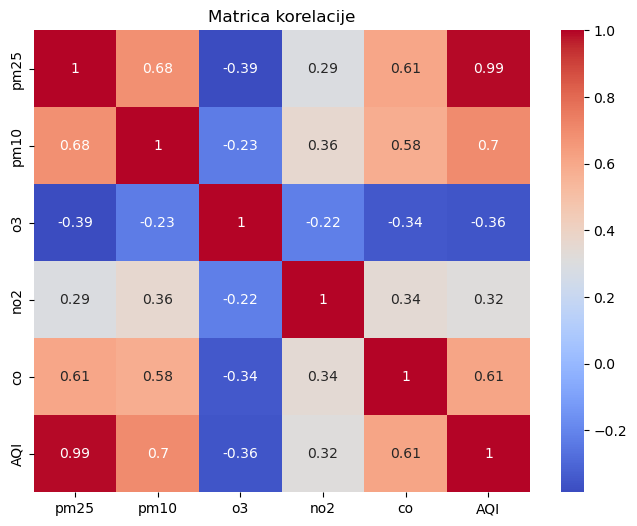

In [9]:
#Matrica korelacije
plt.figure(figsize=(8,6))
sns.heatmap(Beograd.corr(), annot=True, cmap="coolwarm")
plt.title("Matrica korelacije")

In [10]:
#Kreiranje trening data
AQI_val = Beograd.filter(["AQI"])
dataset = AQI_val.values
training_data_len = int(np.ceil(len(dataset)*0.9875))

In [11]:
# Standradizacija vrednosti za unos u LSTM model
scaler= StandardScaler()
scaled_data= scaler.fit_transform(dataset)

training_data = scaled_data[:training_data_len]

X_train, y_train = [], []

In [12]:
# Kreiranje prozora(window) za posmatranje vrednosti unutar modela
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [13]:
# Kreiranje modela
model = keras.models.Sequential()
# Kreiranje 1. nivoa
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))
# Kreiranje 2. nivoa
model.add(keras.layers.LSTM(64, return_sequences=False))
# Kreiranje 3. nivoa
model.add(keras.layers.Dense(128, activation="relu"))
# Kreiranje 4. nivoa
model.add(keras.layers.Dropout(0.5))
# Kreiranje konacnog nivoa
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

E:\anaconda\envs\python_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#pokretanje modela
training = model.fit(X_train, y_train, epochs=20, batch_size=32)

test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]


for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))


Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.5441 - root_mean_squared_error: 0.7495
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4938 - root_mean_squared_error: 0.6863
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.4367 - root_mean_squared_error: 0.6089
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4118 - root_mean_squared_error: 0.5841
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4139 - root_mean_squared_error: 0.5816
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.4119 - root_mean_squared_error: 0.5853
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4073 - root_mean_squared_error: 0.5822
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4068 - root_mean_squared_error: 0.5795
Epoch 9/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.4036 - root_mean_squared_error: 0.5768
Epoch 10/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4011 - root_mean_s

In [15]:
# Vrsenje predvidjana vrednosti
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step


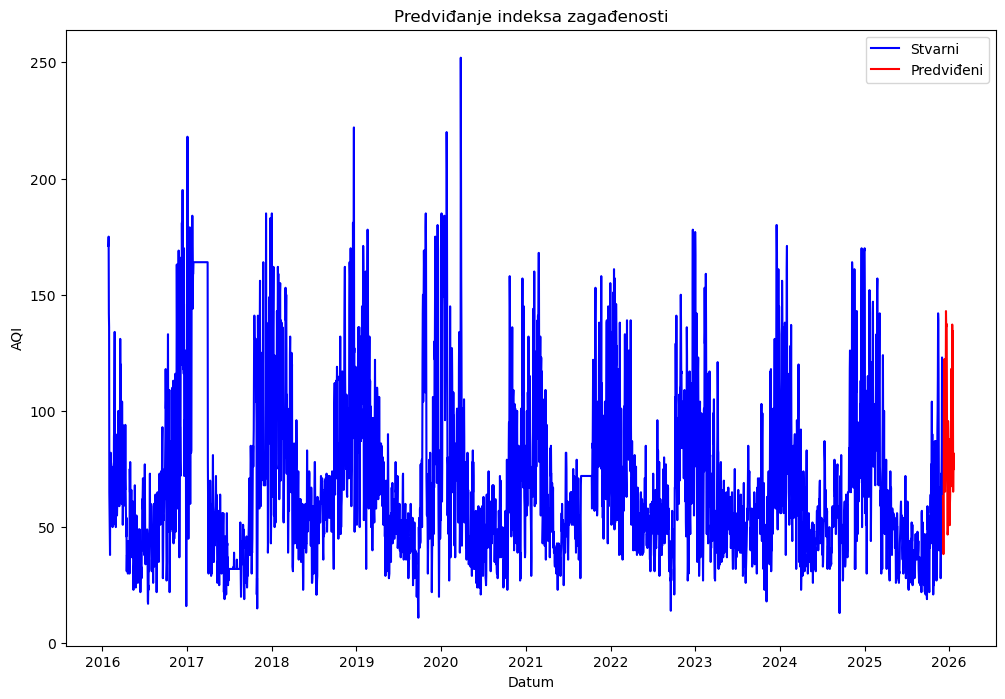

In [16]:
# Prikaz rezultata na grafikonu
train = Beograd[:training_data_len]
test =  Beograd[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(12,8))
plt.plot(train.index, train['AQI'], label="Stvarni", color='blue')
plt.plot(test.index, test['Predictions'], label="Predviđeni", color='red')
plt.title("Predviđanje indeksa zagađenosti")
plt.xlabel("Datum")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [17]:
# Prikaz konkretnih predvidjenih vrednosti
test['Predictions']


date
2025-12-05     63.284023
2025-12-06     46.564793
2025-12-07     38.369049
2025-12-08     46.986092
2025-12-09    103.688011
2025-12-10    115.557365
2025-12-11    122.274399
2025-12-12     82.788277
2025-12-13     68.458427
2025-12-14     65.264679
2025-12-15     70.863762
2025-12-16    102.280884
2025-12-17    110.580368
2025-12-18    142.965637
2025-12-19    136.204422
2025-12-20    137.504242
2025-12-21    137.060501
2025-12-22    107.482353
2025-12-23     76.011589
2025-12-24     79.527954
2025-12-25     46.786819
2025-12-26     48.581875
2025-12-27     95.649895
2025-12-28     91.160873
2025-12-31     62.799812
2026-01-01     67.372978
2026-01-02     69.737282
2026-01-03     50.812862
2026-01-04     59.773262
2026-01-05     63.607937
2026-01-06     87.976997
2026-01-07     80.018974
2026-01-08     81.706566
2026-01-09     83.851860
2026-01-10    118.093704
2026-01-11     98.122047
2026-01-12     71.679276
2026-01-13     67.587402
2026-01-14    137.171814
2026-01-15    117.16

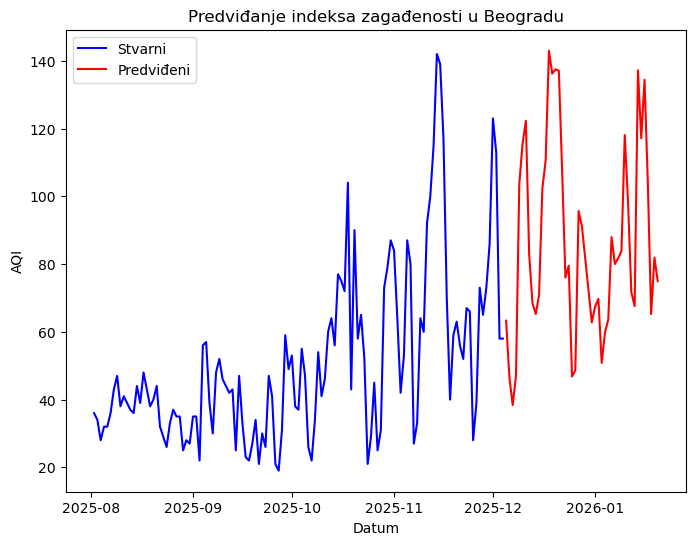

In [19]:
# Kreiranje manjeg i vidljivijeg grafikona
train = Beograd.loc[(Beograd.index > datetime(2025,8,1)) & (Beograd.index < datetime(2025,12,5))]
test =  Beograd[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(8,6))
plt.plot(train.index, train['AQI'], label="Stvarni", color='blue')
plt.plot(test.index, test['Predictions'], label="Predviđeni", color='red')
plt.title("Predviđanje indeksa zagađenosti u Beogradu")
plt.xlabel("Datum")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [21]:
Prognoza_Beograd = pd.DataFrame(test['Predictions'])
Prognoza_Beograd.to_csv('prognoza_beograd.csv')

In [26]:
Prognoza_Beograd['Predictions'] = Prognoza_Beograd['Predictions'].round(0).astype(int)
Prognoza_Beograd

,Predictions
date,
2025-12-05,63
2025-12-06,47
2025-12-07,38
2025-12-08,47
2025-12-09,104
2025-12-10,116
2025-12-11,122
2025-12-12,83
2025-12-13,68


In [27]:
Prognoza_Beograd['Predictions'].mean()

np.float64(87.02222222222223)